In [ ]:
# ==== 环境依赖 ====
# pip install pyomo scipy numpy
# 并准备一个非线性连续求解器（建议 IPOPT）。若无 IPOPT，可先试 Couenne/Bonmin 或者把目标改成能被二阶锥/二次求解的形式。

import numpy as np
from scipy.spatial import Delaunay
import itertools as it
import pyomo.environ as pyo
from pyomo.contrib.piecewise import PiecewiseLinearFunction
from pyomo.core.base import TransformationFactory


# ----------------------- 组件清理 -----------------------
def del_components(model):
    for comp in ['obj', 'As', 'pw', 'pw_fun', 'pw_As', 'pw_link',
                 'bary_lam', 'bary_sum', 'bary_link']:
        if hasattr(model, comp):
            model.del_component(comp)

# ----------------------- 角点生成 -----------------------
def corners_from_bounds(firt_stg_vars):
    bounds = []
    for y in firt_stg_vars:
        lb, ub = y.lb, y.ub
        if lb is None or ub is None:
            raise ValueError(f"{y.name} 缺少上下界，无法生成角点")
        bounds.append((float(lb), float(ub)))
    return list(it.product(*[(lb, ub) for (lb, ub) in bounds]))

# ----------------------- n 维分片 -----------------------
def add_nd_piecewise(model, firt_stg_vars, points, values,
                     name="pw", relation="==", round_ndigits=12):
    if len(points) == 0:
        raise ValueError("points 不能为空")
    N = len(firt_stg_vars)
    for pt in points:
        if len(pt) != N:
            raise ValueError(f"points 中出现与 x_vars 维度不一致的点: {pt}")
    # 先清掉旧件（注意：会把 obj/As/pw 等都删掉）
    if hasattr(model, 'obj'): model.del_component('obj')
    if hasattr(model, 'As'):  model.del_component('As')
    for comp in ['pw', 'pw_fun', 'pw_As', 'pw_link']:
        if hasattr(model, comp):
            model.del_component(comp)

    def keyize(coords):
        return tuple(round(float(c), round_ndigits) for c in coords)
    norm_points = [keyize(pt) for pt in points]

    if isinstance(values, dict):
        table = {keyize(k): float(v) for k, v in values.items()}
        miss = [pt for pt in norm_points if pt not in table]
        if miss:
            raise KeyError(f"values 缺少这些点的取值: {miss[:5]}{' ...' if len(miss)>5 else ''}")
    else:
        if len(values) != len(points):
            raise ValueError("values 长度应与 points 数量一致（或传 dict）")
        table = {pt: float(v) for pt, v in zip(norm_points, values)}

    def _f_from_table(*coords):
        return table[keyize(coords)]

    pw = PiecewiseLinearFunction(points=norm_points, function=_f_from_table, name=f"{name}_fun")
    model.add_component(pw.name, pw)
    pw_expr = pw(*firt_stg_vars)

    As = pyo.Var(name=f"{name}_As")
    model.add_component(As.name, As)
    if relation == "==":
        link = pyo.Constraint(expr=As == pw_expr)
    elif relation == ">=":
        link = pyo.Constraint(expr=As >= pw_expr)
    elif relation == "<=":
        link = pyo.Constraint(expr=As <= pw_expr)
    else:
        raise ValueError("relation 只能是 '==', '>=', '<='")
    model.add_component(f"{name}_link", link)

    # 把 pw 具体化（生成内部 λ 等变量/约束）
    # 把 pw 具体化（生成内部 λ/约束）
    try:
        TransformationFactory('contrib.piecewise').apply_to(model)
    except Exception:
        # 极少数旧版本可能用不同注册名，兜底再试一次
        TransformationFactory('contrib.piecewise.piecewise').apply_to(model)

    return As, pw

# ----------------------- 真函数（多极小值） -----------------------
# 选个好用的：平移版 Rastrigin（多局部极小值），中心在 (5,5,5)
def f_true_expr(m):
    # f(x) = sum((x_i-5)^2 - 10*cos(2*pi*(x_i-5))) + 30
    terms = []
    for i in m.I:
        xi = m.x[i] - 5.0
        terms.append( (xi**2) - 10.0*pyo.cos(2.0*np.pi*xi) )
    return sum(terms) + 30.0

def f_true_numpy(x):
    z = x - 5.0
    return np.sum(z**2 - 10.0*np.cos(2.0*np.pi*z)) + 30.0

# ----------------------- 建模：3维 & 边界 [0,10]^3 -----------------------
def build_base_model():
    m = pyo.ConcreteModel()
    m.dim = 3
    m.I = range(m.dim)
    m.x = pyo.Var(m.I, bounds=(0.0, 10.0))  # 10x10x10 立方体
    return m

# ----------------------- 单形内的线性（重心坐标）约束 -----------------------
def add_simplex_barycentric_constraints(model, verts):
    """
    verts: (d+1, d) numpy array. 这里 d=3, 单形顶点有4个，每个是3维坐标
    约束：
        x = sum_j lam[j] * v_j
        sum_j lam[j] = 1
        lam[j] >= 0
    """
    d = len(model.I)
    k = len(verts)    # 应为 d+1
    assert k == d+1, "3 维单形应有 4 个顶点"
    # 新增 λ 变量/约束，用特定名字，便于删除
    model.bary_lam = pyo.Var(range(k), domain=pyo.NonNegativeReals)
    model.bary_sum = pyo.Constraint(expr=sum(model.bary_lam[j] for j in range(k)) == 1.0)

    # x_i = sum_j lam_j * v_j[i]
    def _link_rule(m, i):
        return m.x[i] == sum(m.bary_lam[j] * float(verts[j, i]) for j in range(k))
    model.bary_link = pyo.Constraint(model.I, rule=_link_rule)

def drop_simplex_barycentric_constraints(model):
    for name in ['bary_lam', 'bary_sum', 'bary_link', 'obj']:
        if hasattr(model, name):
            model.del_component(name)

# ----------------------- 逐单形最小化 f(x)-As(x) -----------------------
def minimize_on_each_simplex(nodes, values, solver='ipopt', tee=False):
    """
    nodes: list[(3,)]
    values: list[val] or dict{tuple(x): val}, 用于建立 PWLF 的 A_s(x)
    """
    pts = np.asarray(nodes, dtype=float)
    tri = Delaunay(pts)

    m = build_base_model()
    # 先建一次 A_s（基于全体 nodes），在每个单形里都可用
    As, _pw = add_nd_piecewise(m, [m.x[i] for i in m.I], points=nodes, values=values,
                               name="pw", relation="==")

    # 结果收集
    results = []
    opt = pyo.SolverFactory(solver)

    for simp_idx, simp in enumerate(tri.simplices):
        verts = pts[simp]     # (4,3)

        # 为该单形添加线性约束
        add_simplex_barycentric_constraints(m, verts)

        # 定义当前单形的目标：min f(x) - As(x)
        obj_expr = f_true_expr(m) - As
        m.obj = pyo.Objective(expr=obj_expr, sense=pyo.minimize)

        res = opt.solve(m, tee=tee)
        xstar = np.array([pyo.value(m.x[i]) for i in m.I])
        fval  = f_true_numpy(xstar)
        Asval = pyo.value(As)
        gap   = fval - Asval

        results.append({
            "simplex_index": int(simp_idx),
            "vertices_index": simp.tolist(),
            "x_star": xstar.tolist(),
            "f(x*)": float(fval),
            "A_s(x*)": float(Asval),
            "f-As": float(gap),
            "solver_status": str(res.solver.status),
            "termination": str(res.solver.termination_condition),
        })

        # 清理该单形专属的约束与目标，换下一个单形
        drop_simplex_barycentric_constraints(m)

    return results

# ----------------------- Demo 主程序 -----------------------
if __name__ == "__main__":
    rng = np.random.default_rng(0)

    # 1) 随机节点 + 角点（可选）作为 PWLF 的节点
    #    为了稳定，建议把中心附近多给点（Rastrigin 的起伏在整域都有）
    random_nodes = rng.uniform(0.0, 10.0, size=(12, 3))   # 12 个随机点
    # 亦可把角点加入：有时能避免 PWLF 在边界不稳
    # corners = list(it.product([0.0, 10.0], repeat=3))
    # nodes = np.vstack([random_nodes, np.array(corners, dtype=float)])
    nodes = random_nodes

    # 2) 计算真函数值
    values = [float(f_true_numpy(p)) for p in nodes]

    # 3) 逐单形求 min (f - As)
    res = minimize_on_each_simplex(nodes.tolist(), values, solver="ipopt", tee=False)

    # 4) 打印部分结果
    print(f"单形数量：{len(res)}")
    best = min(res, key=lambda r: r["f-As"])
    print("最小 f-As 单形：", best["simplex_index"])
    print("x* =", best["x_star"], "  f-As =", best["f-As"])


AttributeError: 'NoneType' object has no attribute 'apply_to'

In [ ]:
        bounds.append((float(lb), float(ub)))
    return list(it.product(*[(lb, ub) for (lb, ub) in bounds]))

# ----------------------- n 维分片 -----------------------
def add_nd_piecewise(model, firt_stg_vars, points, values,
                     name="pw", relation="==", round_ndigits=12):
    if len(points) == 0:
        raise ValueError("points 不能为空")
    N = len(firt_stg_vars)
    for pt in points:
        if len(pt) != N:
            raise ValueError(f"points 中出现与 x_vars 维度不一致的点: {pt}")
    # 先清掉旧件（注意：会把 obj/As/pw 等都删掉）
    if hasattr(model, 'obj'): model.del_component('obj')
    if hasattr(model, 'As'):  model.del_component('As')
    for comp in ['pw', 'pw_fun', 'pw_As', 'pw_link']:
        if hasattr(model, comp):
            model.del_component(comp)

    def keyize(coords):
        return tuple(round(float(c), round_ndigits) for c in coords)
    norm_points = [keyize(pt) for pt in points]

    if isinstance(values, dict):
        table = {keyize(k): float(v) for k, v in values.items()}
        miss = [pt for pt in norm_points if pt not in table]
        if miss:
            raise KeyError(f"values 缺少这些点的取值: {miss[:5]}{' ...' if len(miss)>5 else ''}")
    else:
        if len(values) != len(points):
            raise ValueError("values 长度应与 points 数量一致（或传 dict）")
        table = {pt: float(v) for pt, v in zip(norm_points, values)}

    def _f_from_table(*coords):
        return table[keyize(coords)]

    pw = PiecewiseLinearFunction(points=norm_points, function=_f_from_table, name=f"{name}_fun")
    model.add_component(pw.name, pw)
    pw_expr = pw(*firt_stg_vars)

    As = pyo.Var(name=f"{name}_As")
    model.add_component(As.name, As)
    if relation == "==":
        link = pyo.Constraint(expr=As == pw_expr)
    elif relation == ">=":
        link = pyo.Constraint(expr=As >= pw_expr)
    elif relation == "<=":
        link = pyo.Constraint(expr=As <= pw_expr)
    else:
        raise ValueError("relation 只能是 '==', '>=', '<='")
    model.add_component(f"{name}_link", link)

    # 把 pw 具体化（生成内部 λ 等变量/约束）
    # 把 pw 具体化（生成内部 λ/约束）
    try:
        TransformationFactory('contrib.piecewise').apply_to(model)
    except Exception:
        # 极少数旧版本可能用不同注册名，兜底再试一次
        TransformationFactory('contrib.piecewise.piecewise').apply_to(model)

    return As, pw

# ----------------------- 真函数（多极小值） -----------------------
# 选个好用的：平移版 Rastrigin（多局部极小值），中心在 (5,5,5)
def f_true_expr(m):
    # f(x) = sum((x_i-5)^2 - 10*cos(2*pi*(x_i-5))) + 30
    terms = []
    for i in m.I:
        xi = m.x[i] - 5.0
        terms.append( (xi**2) - 10.0*pyo.cos(2.0*np.pi*xi) )
    return sum(terms) + 30.0

def f_true_numpy(x):
    z = x - 5.0
    return np.sum(z**2 - 10.0*np.cos(2.0*np.pi*z)) + 30.0

# ----------------------- 建模：3维 & 边界 [0,10]^3 -----------------------
def build_base_model():
    m = pyo.ConcreteModel()
    m.dim = 3
    m.I = range(m.dim)
    m.x = pyo.Var(m.I, bounds=(0.0, 10.0))  # 10x10x10 立方体
    return m

# ----------------------- 单形内的线性（重心坐标）约束 -----------------------
def add_simplex_barycentric_constraints(model, verts):
    """
    verts: (d+1, d) numpy array. 这里 d=3, 单形顶点有4个，每个是3维坐标
    约束：
        x = sum_j lam[j] * v_j
        sum_j lam[j] = 1
        lam[j] >= 0
    """
    d = len(model.I)
    k = len(verts)    # 应为 d+1
    assert k == d+1, "3 维单形应有 4 个顶点"
    # 新增 λ 变量/约束，用特定名字，便于删除
    model.bary_lam = pyo.Var(range(k), domain=pyo.NonNegativeReals)
    model.bary_sum = pyo.Constraint(expr=sum(model.bary_lam[j] for j in range(k)) == 1.0)

    # x_i = sum_j lam_j * v_j[i]
    def _link_rule(m, i):
        return m.x[i] == sum(m.bary_lam[j] * float(verts[j, i]) for j in range(k))
    model.bary_link = pyo.Constraint(model.I, rule=_link_rule)

def drop_simplex_barycentric_constraints(model):
    for name in ['bary_lam', 'bary_sum', 'bary_link', 'obj']:
        if hasattr(model, name):
            model.del_component(name)

# ----------------------- 逐单形最小化 f(x)-As(x) -----------------------
def minimize_on_each_simplex(nodes, values, solver='ipopt', tee=False):
    """
    nodes: list[(3,)]
    values: list[val] or dict{tuple(x): val}, 用于建立 PWLF 的 A_s(x)
    """
    pts = np.asarray(nodes, dtype=float)
    tri = Delaunay(pts)

    m = build_base_model()
    # 先建一次 A_s（基于全体 nodes），在每个单形里都可用
    As, _pw = add_nd_piecewise(m, [m.x[i] for i in m.I], points=nodes, values=values,
                               name="pw", relation="==")

    # 结果收集
    results = []
    opt = pyo.SolverFactory(solver)

    for simp_idx, simp in enumerate(tri.simplices):
        verts = pts[simp]     # (4,3)

        # 为该单形添加线性约束
        add_simplex_barycentric_constraints(m, verts)

        # 定义当前单形的目标：min f(x) - As(x)
        obj_expr = f_true_expr(m) - As
        m.obj = pyo.Objective(expr=obj_expr, sense=pyo.minimize)

        res = opt.solve(m, tee=tee)
        xstar = np.array([pyo.value(m.x[i]) for i in m.I])
        fval  = f_true_numpy(xstar)
        Asval = pyo.value(As)
        gap   = fval - Asval

        results.append({
            "simplex_index": int(simp_idx),
            "vertices_index": simp.tolist(),
            "x_star": xstar.tolist(),
            "f(x*)": float(fval),
            "A_s(x*)": float(Asval),
            "f-As": float(gap),
            "solver_status": str(res.solver.status),
            "termination": str(res.solver.termination_condition),
        })

        # 清理该单形专属的约束与目标，换下一个单形
        drop_simplex_barycentric_constraints(m)

    return results

# ----------------------- Demo 主程序 -----------------------
if __name__ == "__main__":
    rng = np.random.default_rng(0)

    # 1) 随机节点 + 角点（可选）作为 PWLF 的节点
    #    为了稳定，建议把中心附近多给点（Rastrigin 的起伏在整域都有）
    random_nodes = rng.uniform(0.0, 10.0, size=(12, 3))   # 12 个随机点
    # 亦可把角点加入：有时能避免 PWLF 在边界不稳
    # corners = list(it.product([0.0, 10.0], repeat=3))
    # nodes = np.vstack([random_nodes, np.array(corners, dtype=float)])
    nodes = random_nodes

    # 2) 计算真函数值
    values = [float(f_true_numpy(p)) for p in nodes]

    # 3) 逐单形求 min (f - As)
    res = minimize_on_each_simplex(nodes.tolist(), values, solver="ipopt", tee=False)

    # 4) 打印部分结果
    print(f"单形数量：{len(res)}")
    best = min(res, key=lambda r: r["f-As"])
    print("最小 f-As 单形：", best["simplex_index"])
    print("x* =", best["x_star"], "  f-As =", best["f-As"])


In [2]:
import numpy as np
from scipy.spatial import Delaunay
import itertools as it
import pyomo.environ as pyo

# ---------- 真函数（多极小值） ----------
def f_true_expr(m):
    # Rastrigin 平移到 (5,5,5)
    return sum((m.x[i]-5)**2 - 10*pyo.cos(2*np.pi*(m.x[i]-5)) for i in m.I) + 30

def f_true_numpy(x):
    z = x - 5.0
    return float(np.sum(z**2 - 10.0*np.cos(2.0*np.pi*z)) + 30.0)

# ---------- 基础模型 ----------
def build_base_model():
    m = pyo.ConcreteModel()
    m.dim = 3
    m.I = range(m.dim)
    m.x = pyo.Var(m.I, bounds=(0.0, 10.0))  # 10x10x10
    return m

def drop_simplex_stuff(m):
    for nm in ['lam','lam_sum','x_link','As','obj']:
        if hasattr(m, nm):
            m.del_component(nm)

# ---------- 在每个单形内最小化 f(x) - As(x)（As 用重心坐标定义） ----------
def minimize_on_each_simplex(nodes, values, solver='ipopt', tee=False):
    pts = np.asarray(nodes, dtype=float)        # (N,3)
    vals= np.asarray(values, dtype=float)       # (N,)
    tri = Delaunay(pts)                         # tri.simplices: (K,4) 索引

    m = build_base_model()
    opt = pyo.SolverFactory(solver)
    results = []

    for k, simp in enumerate(tri.simplices):
        verts = pts[simp]           # (4,3)
        fverts= vals[simp]          # (4,)

        # 1) 重心变量 lam_j
        m.lam = pyo.Var(range(4), domain=pyo.NonNegativeReals)
        m.lam_sum = pyo.Constraint(expr=sum(m.lam[j] for j in range(4)) == 1.0)

        # 2) x = sum_j lam_j * v_j（线性）
        def _link_rule(mm, i):
            return mm.x[i] == sum(mm.lam[j]*float(verts[j,i]) for j in range(4))
        m.x_link = pyo.Constraint(m.I, rule=_link_rule)

        # 3) As = sum_j lam_j * f(v_j)
        m.As = pyo.Var()
        m.As_con = pyo.Constraint(expr=m.As == sum(m.lam[j]*float(fverts[j]) for j in range(4)))

        # 4) 目标：min f(x) - As
        m.obj = pyo.Objective(expr=f_true_expr(m) - m.As, sense=pyo.minimize)

        res = opt.solve(m, tee=tee)

        xstar = np.array([pyo.value(m.x[i]) for i in m.I])
        results.append({
            "simplex_index": int(k),
            "vertices_index": simp.tolist(),
            "x_star": xstar.tolist(),
            "f(x*)": f_true_numpy(xstar),
            "A_s(x*)": float(pyo.value(m.As)),
            "f-As": float(pyo.value(m.obj)),
            "status": str(res.solver.status),
            "term": str(res.solver.termination_condition),
        })

        drop_simplex_stuff(m)

    return results

# ---------- Demo ----------
if __name__ == "__main__":
    rng = np.random.default_rng(0)
    nodes = rng.uniform(0.0, 10.0, size=(12, 3))          # 随机节点
    # 也可加角点增强稳定性：
    # nodes = np.vstack([nodes, np.array(list(it.product([0,10],[0,10],[0,10])), float)])
    values = [f_true_numpy(p) for p in nodes]

    res = minimize_on_each_simplex(nodes.tolist(), values, solver="ipopt", tee=False)
    print("单形数量：", len(res))
    best = min(res, key=lambda r: r["f-As"])
    print("最小 f-As 单形：", best["simplex_index"])
    print("x* =", best["x_star"], "  f-As =", best["f-As"])


'pyomo.core.base.constraint.ScalarConstraint'>) on block unknown with a new
Component (type=<class
'pyomo.core.base.constraint.AbstractScalarConstraint'>). This is usually
indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().
'pyomo.core.base.constraint.ScalarConstraint'>) on block unknown with a new
Component (type=<class
'pyomo.core.base.constraint.AbstractScalarConstraint'>). This is usually
indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().
'pyomo.core.base.constraint.ScalarConstraint'>) on block unknown with a new
Component (type=<class
'pyomo.core.base.constraint.AbstractScalarConstraint'>). This is usually
indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().
'pyomo.core.base.constraint.ScalarConstraint'>) on block unknown with a new
Component (type=<class
'pyomo.core.base.constraint.AbstractScalarConstraint'>). T

In [5]:
# pip install pyomo scipy numpy
# 建议安装 IPOPT；若没有，可把 solver 改成 'bonmin' 或 'couenne' 试跑

import numpy as np
import itertools as it
from scipy.spatial import Delaunay
import pyomo.environ as pyo

# -------- 真函数（二维 Rastrigin，中心平移到(5,5)） --------
def f_true_expr(m):
    # f(x) = Σ[(x_i-5)^2 - 10 cos(2π(x_i-5))] + 20
    return sum((m.x[i]-5)**2 - 10*pyo.cos(2*np.pi*(m.x[i]-5)) for i in m.I) + 20

def f_true_numpy(x):
    z = x - 5.0
    return float(np.sum(z**2 - 10.0*np.cos(2.0*np.pi*z)) + 20.0)

# -------- 基础模型：2 维 & [0,10]^2 --------
def build_base_model_2d():
    m = pyo.ConcreteModel()
    m.dim = 2
    m.I = range(m.dim)
    m.x = pyo.Var(m.I, bounds=(0.0, 10.0))
    return m

def drop_triangle_block_and_obj(m):
    for nm in ['tri', 'obj']:
        if hasattr(m, nm):
            m.del_component(nm)

# -------- 逐三角形：min f(x) - As(x)，As 用重心坐标定义 --------
def minimize_on_each_triangle(nodes, values, solver='ipopt', tee=False):
    pts  = np.asarray(nodes, dtype=float)   # (N,2)
    vals = np.asarray(values, dtype=float)  # (N,)
    tri  = Delaunay(pts)                    # tri.simplices: (K,3)

    m = build_base_model_2d()
    opt = pyo.SolverFactory(solver)
    results = []

    # As 全局只建一次；每个三角形用不同等式来约束它
    if hasattr(m, 'As'):
        m.del_component('As')
    m.As = pyo.Var()

    x_last = None  # 简单 warm-start
    for k, simp in enumerate(tri.simplices):
        V = pts[simp]     # (3,2) 顶点坐标
        F = vals[simp]    # (3,)   顶点函数值

        # Warm-start
        if x_last is None:
            for i in m.I: m.x[i].value = 5.0
        else:
            for i in m.I: m.x[i].value = x_last[i]

        # —— 每个三角形放进一个 Block 里，便于清理 ——
        m.tri = pyo.Block()

        # 重心坐标 λ_j ≥ 0, sum λ = 1
        m.tri.lam = pyo.Var(range(3), domain=pyo.NonNegativeReals)
        m.tri.lam_sum = pyo.Constraint(expr=sum(m.tri.lam[j] for j in range(3)) == 1.0)

        # x = Σ λ_j v_j（线性绑定）
        def _link_rule(_b, i):
            return m.x[i] == sum(_b.lam[j]*float(V[j, i]) for j in range(3))
        m.tri.x_link = pyo.Constraint(m.I, rule=_link_rule)

        # As = Σ λ_j f(v_j)
        m.tri.As_con = pyo.Constraint(expr=m.As == sum(m.tri.lam[j]*float(F[j]) for j in range(3)))

        # 当前三角形目标
        m.obj = pyo.Objective(expr=f_true_expr(m) - m.As, sense=pyo.minimize)

        res = opt.solve(m, tee=tee)

        x_star = [pyo.value(m.x[i]) for i in m.I]
        f_val  = f_true_numpy(np.array(x_star))
        As_val = float(pyo.value(m.As))
        gap    = float(pyo.value(m.obj))
        results.append({
            "triangle_index": int(k),
            "vertices_index": simp.tolist(),
            "x_star": x_star,
            "f(x*)": f_val,
            "A_s(x*)": As_val,
            "f-As": gap,
            "status": str(res.solver.status),
            "term": str(res.solver.termination_condition),
        })

        x_last = x_star
        drop_triangle_block_and_obj(m)

    return results

# -------- Demo --------
if __name__ == "__main__":
    rng = np.random.default_rng(1)
    # 随机采样 + 角点，避免退化三角形
    rand_pts = rng.uniform(0.0, 10.0, size=(10, 2))
    corners = np.array(list(it.product([0.0, 10.0], repeat=2)), dtype=float)
    nodes = np.vstack([rand_pts, corners])   # 至少 6+ 点以保证剖分稳定
    values = [f_true_numpy(p) for p in nodes]

    res = minimize_on_each_triangle(nodes.tolist(), values, solver="ipopt", tee=False)
    print("三角形数量：", len(res))
    best = min(res, key=lambda r: r["f-As"])
    print("最小 f-As 三角形：", best["triangle_index"])
    print("x* =", best["x_star"], "  f-As =", best["f-As"])


WARNING (W1002): Setting Var 'x[1]' to a numeric value `10.000000003940874`
outside the bounds (0.0, 10.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
三角形数量： 22
最小 f-As 三角形： 8
x* = [7.004975762770564, 6.003329634673381]   f-As = -37.545316451541105


In [3]:
# pip install pyomo scipy numpy
# 建议 solver 用 IPOPT；若没有，可尝试 'bonmin' 或 'couenne'
import numpy as np
import itertools as it
from scipy.spatial import Delaunay
import pyomo.environ as pyo

# ---- 真函数（二维 Rastrigin，中心平移到(5,5)）----
def f_true_expr(m):
    return ((m.x-5)**2 - 10*pyo.cos(2*np.pi*(m.x-5))
          + (m.y-5)**2 - 10*pyo.cos(2*np.pi*(m.y-5)) + 20)

def f_true_numpy(xy):
    z = np.asarray(xy, float) - 5.0
    return float(np.sum(z**2 - 10.0*np.cos(2.0*np.pi*z)) + 20.0)

# ---- 基础模型：m.x, m.y ∈ [0,10] ----
def build_base_model_2d():
    m = pyo.ConcreteModel()
    m.x = pyo.Var(bounds=(0.0, 10.0))
    m.y = pyo.Var(bounds=(0.0, 10.0))
    return m

def drop_triangle_block_and_obj(m):
    for nm in ['tri', 'obj']:
        if hasattr(m, nm):
            m.del_component(nm)

# ---- 逐三角形：min f(x,y) - As（As=顶点值的凸组合）----
def minimize_on_each_triangle(nodes, values, solver='ipopt', tee=False):
    pts  = np.asarray(nodes, dtype=float)   # (N,2)
    vals = np.asarray(values, dtype=float)  # (N,)
    tri  = Delaunay(pts)                    # tri.simplices: (K,3)

    m = build_base_model_2d()
    opt = pyo.SolverFactory(solver)
    results = []

    # As 全局只建一次；每个三角形用不同等式来约束它
    if hasattr(m, 'As'):
        m.del_component('As')
    m.As = pyo.Var()

    x_last = None  # 简单 warm-start
    for k, simp in enumerate(tri.simplices):
        V = pts[simp]     # (3,2): 顶点坐标 (vx, vy)
        F = vals[simp]    # (3,): 顶点的 f 值

        # warm start
        if x_last is None:
            m.x.value = 5.0; m.y.value = 5.0
        else:
            m.x.value, m.y.value = x_last

        # —— 每个三角形放进 Block，便于清理 ——
        m.tri = pyo.Block()

        # 重心坐标 lam_j ≥ 0, sum λ = 1
        m.tri.lam = pyo.Var(range(3), domain=pyo.NonNegativeReals)
        m.tri.lam_sum = pyo.Constraint(expr=sum(m.tri.lam[j] for j in range(3)) == 1.0)

        # x = Σ λ_j * vx_j,  y = Σ λ_j * vy_j
        m.tri.x_link = pyo.Constraint(expr=m.x == sum(m.tri.lam[j]*float(V[j,0]) for j in range(3)))
        m.tri.y_link = pyo.Constraint(expr=m.y == sum(m.tri.lam[j]*float(V[j,1]) for j in range(3)))

        # As = Σ λ_j * f(v_j)
        m.tri.As_con = pyo.Constraint(expr=m.As == sum(m.tri.lam[j]*float(F[j]) for j in range(3)))

        # 当前三角形目标
        m.obj = pyo.Objective(expr=f_true_expr(m) - m.As, sense=pyo.minimize)

        res = opt.solve(m, tee=tee)

        x_star = (pyo.value(m.x), pyo.value(m.y))
        f_val  = f_true_numpy(x_star)
        As_val = float(pyo.value(m.As))
        gap    = float(pyo.value(m.obj))
        results.append({
            "triangle_index": int(k),
            "vertices_index": simp.tolist(),
            "x_star": [float(x_star[0]), float(x_star[1])],
            "f(x*)": f_val,
            "A_s(x*)": As_val,
            "f-As": gap,
            "status": str(res.solver.status),
            "term": str(res.solver.termination_condition),
        })

        x_last = x_star
        drop_triangle_block_and_obj(m)

    return results

# ---- Demo ----
if __name__ == "__main__":
    rng = np.random.default_rng(1)
    rand_pts = rng.uniform(0.0, 10.0, size=(10, 2))
    corners = np.array(list(it.product([0.0, 10.0], repeat=2)), dtype=float)
    nodes = np.vstack([rand_pts, corners])
    values = [f_true_numpy(p) for p in nodes]

    res = minimize_on_each_triangle(nodes.tolist(), values, solver="ipopt", tee=False)
    print("三角形数量：", len(res))
    best = min(res, key=lambda r: r["f-As"])
    print("最小 f-As 三角形：", best["triangle_index"])
    print("x* =", best["x_star"], "  f-As =", best["f-As"])


WARNING (W1002): Setting Var 'y' to a numeric value `10.000000003940874`
outside the bounds (0.0, 10.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
三角形数量： 22
最小 f-As 三角形： 8
x* = [7.004975762770564, 6.003329634673381]   f-As = -37.545316451541105


In [5]:
import matplotlib.pyplot as plt
from matplotlib.projections import register_projection
from mpl_toolkits.mplot3d import Axes3D

register_projection(Axes3D)               # 手动登记 '3d' 投影

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot([0,1],[0,1],[0,1])
plt.close(fig)



In [9]:
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d  # 必须有这行
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
plt.close(fig)


ValueError: Unknown projection '3d'

<Figure size 640x480 with 0 Axes>

WARNING (W1002): Setting Var 'x' to a numeric value `10.000000002380455`
outside the bounds (0.0, 10.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'y' to a numeric value `10.000000024917124`
outside the bounds (0.0, 10.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
共 26 个三角形
tri   0: ms = -30.1805, x* = [2.0027396404018276, 5.994958637652863] ...
tri   1: ms = -28.2251, x* = [3.0017618178200784, 6.993177975378809] ...
tri   2: ms = -10.8284, x* = [3.008027644640501, 6.593770211834471] ...
tri   3: ms = -21.0202, x* = [10.000000002380455, 6.989912233706155] ...
tri   4: ms = -9.3011, x* = [8.979783860283892, 0.033513468873207664] ...
min ms @ tri = 18 , ms = -39.35114050798728


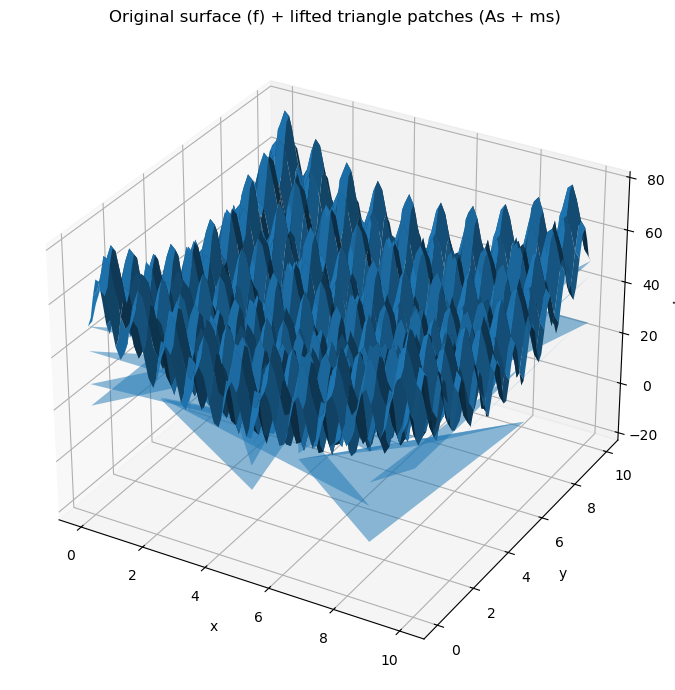

In [ ]:
# pip install numpy scipy pyomo matplotlib  (本地环境已装的话可忽略)

import numpy as np
import itertools as it
from scipy.spatial import Delaunay
import pyomo.environ as pyo
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 只为注册 '3d' 投影，不直接使用



# ---------- 真函数（二维 Rastrigin, 平移到 (5,5)） ----------
def f_true_numpy(xy):
    z = np.asarray(xy, float) - 5.0
    return float(np.sum(z**2 - 10.0*np.cos(2.0*np.pi*z)) + 20.0)

def f_true_expr(m):
    return ((m.x-5)**2 - 10*pyo.cos(2*np.pi*(m.x-5))
          + (m.y-5)**2 - 10*pyo.cos(2*np.pi*(m.y-5)) + 20)

# ---------- 基础模型 ----------
def build_base_model_2d2222222():
    m = pyo.ConcreteModel()
    m.x = pyo.Var(bounds=(0.0, 10.0))
    m.y = pyo.Var(bounds=(0.0, 10.0))
    return m
# ---------- 基础模型 ----------
def build_base_model_2d():
    # 变量与边界
    m = pyo.ConcreteModel()
    m.x = pyo.Var(bounds=(0.0, 10.0))
    m.y = pyo.Var(bounds=(0.0, 10.0))

    # 目标：双阱 + y方向二次
    m.obj = pyo.Objective(
        expr=(m.x - 3)**4 - 8*(m.x - 3)**2 + (m.y - 5)**2,
        sense=pyo.minimize
    )
    return m




def drop_triangle_block_and_obj(m):
    for nm in ['tri', 'obj']:
        if hasattr(m, nm):
            m.del_component(nm)

# ---------- 逐三角形最小化 f-As，返回每个三角形的 ms 和 x* ----------
def per_triangle_ms(nodes, values, solver='ipopt', tee=False):
    pts  = np.asarray(nodes, dtype=float)   # (N,2)
    vals = np.asarray(values, dtype=float)  # (N,)
    tri  = Delaunay(pts)                    # tri.simplices: (K,3)

    m = build_base_model_2d()
    opt = pyo.SolverFactory(solver)
    results = []

    # As 全局只建一次（片内用等式关联）
    if hasattr(m, 'As'):
        m.del_component('As')
    m.As = pyo.Var()

    x_last = None
    for k, simp in enumerate(tri.simplices):
        V = pts[simp]   # (3,2): 顶点坐标
        F = vals[simp]  # (3,)  : 顶点 f 值

        if x_last is None:
            m.x.value = 5.0; m.y.value = 5.0
        else:
            m.x.value, m.y.value = x_last

        # —— Block 装片内组件，便于清理 ——
        m.tri = pyo.Block()
        m.tri.lam = pyo.Var(range(3), domain=pyo.NonNegativeReals)
        m.tri.lam_sum = pyo.Constraint(expr=sum(m.tri.lam[j] for j in range(3)) == 1.0)

        m.tri.x_link = pyo.Constraint(expr=m.x == sum(m.tri.lam[j]*float(V[j,0]) for j in range(3)))
        m.tri.y_link = pyo.Constraint(expr=m.y == sum(m.tri.lam[j]*float(V[j,1]) for j in range(3)))

        m.tri.As_con = pyo.Constraint(expr=m.As == sum(m.tri.lam[j]*float(F[j]) for j in range(3)))

        m.obj = pyo.Objective(expr=f_true_expr(m) - m.As, sense=pyo.minimize)

        res = opt.solve(m, tee=tee)

        x_star = (pyo.value(m.x), pyo.value(m.y))
        f_val  = f_true_numpy(x_star)
        As_val = float(pyo.value(m.As))
        ms_val = f_val - As_val  # 该三角形的 ms = min(f-As)

        results.append({
            "triangle_index": int(k),
            "vertices_index": simp.tolist(),
            "verts_xy": V.tolist(),
            "verts_f": F.tolist(),
            "x_star": [float(x_star[0]), float(x_star[1])],
            "f(x*)": float(f_val),
            "A_s(x*)": As_val,
            "ms": float(ms_val),
            "status": str(res.solver.status),
            "term": str(res.solver.termination_condition),
        })

        x_last = x_star
        drop_triangle_block_and_obj(m)

    return tri, results

# ---------- 画 原函数表面 + “抬升后的三角形贴片”(As+ms) ----------
def plot_surface_with_lifted_patches(tri, results, xlim=(0,10), ylim=(0,10), grid_n=60, alpha_patch=0.6):
    # 1) 原函数表面
    xs = np.linspace(xlim[0], xlim[1], grid_n)
    ys = np.linspace(ylim[0], ylim[1], grid_n)
    XX, YY = np.meshgrid(xs, ys)
    ZZ = np.vectorize(lambda a,b: f_true_numpy((a,b)))(XX, YY)

    fig = plt.figure(figsize=(9,7))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(XX, YY, ZZ, linewidth=0, antialiased=True)

    # 2) 逐三角形画“As+ms”的平面贴片
    for info in results:
        V = np.asarray(info["verts_xy"])   # (3,2)
        F = np.asarray(info["verts_f"])    # (3,)
        ms = info["ms"]

        # 抬升后的顶点高度：f(v_j) + ms
        verts3d = [(V[j,0], V[j,1], F[j] + ms) for j in range(3)]
        poly = Poly3DCollection([verts3d], alpha=alpha_patch)   # 不指定颜色，使用默认
        ax.add_collection3d(poly)

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('value')
    ax.set_title('Original surface (f) + lifted triangle patches (As + ms)')
    plt.tight_layout()
    plt.show()

# ---------- Demo ----------
if __name__ == "__main__":
    rng = np.random.default_rng(2)
    rand_pts = rng.uniform(0.0, 10.0, size=(12, 2))
    corners = np.array(list(it.product([0.0, 10.0], repeat=2)), dtype=float)
    nodes = np.vstack([rand_pts, corners])
    values = [f_true_numpy(p) for p in nodes]

    tri, res = per_triangle_ms(nodes.tolist(), values, solver="ipopt", tee=False)

    # 打印每个三角形的 ms
    print("共", len(res), "个三角形")
    for r in res[:5]:
        print(f"tri {r['triangle_index']:>3}: ms = {r['ms']:.4f}, x* = {r['x_star']} ...")
    best = min(res, key=lambda d: d["ms"])
    print("min ms @ tri =", best["triangle_index"], ", ms =", best["ms"])

    # 画图
    plot_surface_with_lifted_patches(tri, res, grid_n=70, alpha_patch=0.5)


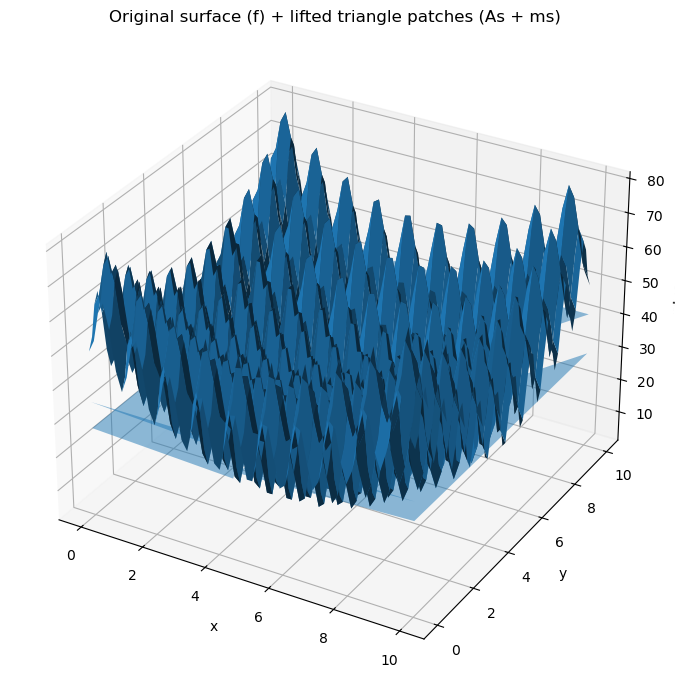

In [9]:
import numpy as np, itertools as it
from sklearn.cluster import KMeans  # 若用kmeans需要: pip install scikit-learn

def make_nodes_random(n_rand=6, include_corners=True, seed=1):
    rng = np.random.default_rng(seed)
    rand_pts = rng.uniform(0.0, 10.0, size=(n_rand, 2))
    nodes = rand_pts
    if include_corners:
        corners = np.array(list(it.product([0.0, 10.0], repeat=2)), float)
        nodes = np.vstack([nodes, corners])
    return nodes

def make_nodes_kmeans(n_pool=200, k=10, include_corners=True, seed=1):
    """先采很多点做聚类，再取聚类中心（更均匀、片数更可控）"""
    rng = np.random.default_rng(seed)
    pool = rng.uniform(0.0, 10.0, size=(n_pool, 2))
    km = KMeans(n_clusters=k, n_init=5, random_state=seed)
    km.fit(pool)
    nodes = km.cluster_centers_
    if include_corners:
        corners = np.array(list(it.product([0.0, 10.0], repeat=2)), float)
        nodes = np.vstack([nodes, corners])
    return nodes

def make_nodes_fps(k=12, include_corners=True, seed=1):
    """Farthest-Point Sampling（蓝噪声风格，避免瘦长三角形）"""
    rng = np.random.default_rng(seed)
    pts = rng.uniform(0.0, 10.0, size=(400, 2))
    # 先从一个随机点开始
    idx = [rng.integers(len(pts))]
    while len(idx) < k:
        chosen = pts[idx]
        d2 = np.min(((pts[:,None,:]-chosen[None,:,:])**2).sum(-1), axis=1)
        idx.append(int(np.argmax(d2)))
    nodes = pts[idx]
    if include_corners:
        corners = np.array(list(it.product([0.0, 10.0], repeat=2)), float)
        nodes = np.vstack([nodes, corners])
    return nodes

# 片更少：把 k 或 n_rand 调小即可
nodes = make_nodes_random(n_rand=1, include_corners=True, seed=2)
# 或
# nodes = make_nodes_kmeans(n_pool=500, k=8, include_corners=True, seed=2)
# 或
# nodes = make_nodes_fps(k=10, include_corners=True, seed=2)

values = [f_true_numpy(p) for p in nodes]
tri, res = per_triangle_ms(nodes.tolist(), values, solver="ipopt", tee=False)
plot_surface_with_lifted_patches(tri, res, grid_n=60, alpha_patch=0.5)
